In [20]:
import sys
import os

# 1. Get the absolute path to the parent directory of this notebook
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '/home/arjunverma/Coding New/Fraud Investigation copilot/src/graph_nb.ipynb'))

# 2. Add it to sys.path if it isn't already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 3. Import the tool directly (without the dots)
from tools import get_account_history as get_account_history_tool

In [21]:
"""
LangGraph workflow for the Fraud Investigation Copilot.

Build order (deliberate): score_node + branch first, tested in isolation.
investigate_node, report_node, and the HITL gate are added in later tasks
once this foundation is confirmed working.
"""

import uuid
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver  # swap for SqliteSaver later (Task 9)

from state import InvestigationState
from scoring import Transaction, score_transaction
from history_store import get_account_history, update_score
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from scoring import check_transaction_fraud
from knowledge_base import search_fraud_patterns
from tools import get_account_history as get_account_history_tool
from langgraph.prebuilt import ToolNode, tools_condition
from langchain.messages import SystemMessage, HumanMessage

load_dotenv()


model = ChatGoogleGenerativeAI(
    model="gemma-4-26b-a4b-it",
    temperature=0.8,  # Gemini 3.0+ defaults to 1.0
)

tools = [get_account_history_tool, search_fraud_patterns, check_transaction_fraud]

SYSTEM_PROMPT = """
You are a Senior Fraud Investigation Copilot. Your objective is to investigate financial transactions that have been flagged by our XGBoost machine learning model. 

You have access to the flagged transaction details and its initial fraud score. You must act as a detective to determine WHY the transaction was flagged and whether it constitutes genuine fraud or a false positive.

### Available Tools:
1. `get_account_history`: Use this to pull the last 50 transactions of either the sender or the receiver. 
   - Call this if the ML model indicates "receiver_degree" or "velocity_score" as top contributing features.
   - Look for signs of mule accounts (new accounts receiving many transfers) or account takeovers (sudden spikes in spending).
2. `search_fraud_patterns`: Use this to query the vector database of known fraud typologies. 
   - Call this if the transaction pattern is ambiguous or if you need precedent for specific merchant categories or geographic anomalies.

### Investigation Protocol:
1. Analyze the Context: Review the transaction details and the specific features that drove the high fraud probability score.
2. Gather Evidence: You MUST use the available tools to gather more context. Do not guess. If the sender's history wasn't enough to clear the flag, check the receiver's history.
3. Synthesize: Compare the transaction against the retrieved history and known fraud patterns. 
4. Formulate a Conclusion: Determine your findings. 

### Output Generation:
Once you have finished using tools and gathering evidence, write a concise, evidence-based Investigation Report. Do not use formatting tools like markdown tables unless absolutely necessary for clarity; stick to clear, logical prose. Highlight the most suspicious elements and recommend a final action (Clear or Escalate to Human).
"""

llm_with_tools = model.bind_tools(tools)
# ---------------------------------------------------------------------
# score_node: deterministic, no LLM involved. Pulls sender history,
# scores the transaction, writes the score into state, and persists
# the score to the DB as a side effect.
# ---------------------------------------------------------------------
def score_node(state: InvestigationState) -> InvestigationState:
    txn_dict = state["transaction"]
    txn = Transaction(**txn_dict)

    sender_history = get_account_history(txn.sender_account, as_sender=True)
    fraud_score = score_transaction(txn, sender_history)

    # Side effect: persist the score against the transaction row.
    # Nodes are allowed DB side effects — only investigation LOGIC flows
    # through state, per our earlier design.
    update_score(
        transaction_id=txn_dict["transaction_id"],
        fraud_probability=fraud_score["fraud_probability"],
        is_flagged=fraud_score["is_flagged"],
    )

    return {**state, "fraud_score": fraud_score}


# ---------------------------------------------------------------------
# Conditional routing: only branch that exists right now.
# ---------------------------------------------------------------------
def route_after_scoring(state: InvestigationState) -> str:
    return "investigate_node" if state["fraud_score"]["is_flagged"] else END


# ---------------------------------------------------------------------
# Placeholder nodes — stubbed so the graph is runnable end-to-end now,
# but these are NOT the real implementations. Replace in later tasks.
# ---------------------------------------------------------------------
def investigate_node(state: InvestigationState) -> InvestigationState:
    # TODO (Task 6): bind tools.get_account_history and
    # knowledge_base.search_fraud_patterns to an LLM, loop until no more
    # tool calls, capped at N iterations.
    transaction = state["transaction"]
    fraud_score = state["fraud_score"]



    response = llm_with_tools.invoke([SystemMessage(content=SYSTEM_PROMPT)] + [HumanMessage(content=f"Investigate the following flagged transaction: {transaction} with fraud score: {fraud_score}")])



    print("[stub] investigate_node reached — flagged transaction, "
          "real tool-calling logic not implemented yet.")
    return {
        **state,
        "account_checks": [],
        "retrieved_patterns": [],
        "messages": [],
    }

tool_node = ToolNode(tools)


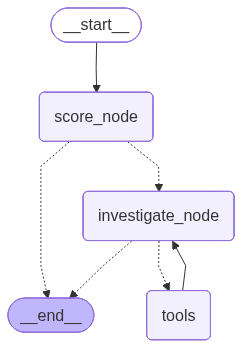

In [22]:
# ---------------------------------------------------------------------
# Build the graph
# ---------------------------------------------------------------------
def build_graph():
    builder = StateGraph(InvestigationState)

    builder.add_node("score_node", score_node)
    builder.add_node("investigate_node", investigate_node)  # stub for now
    builder.add_node("tools", tool_node)

    builder.add_edge(START, "score_node")
    builder.add_conditional_edges(
        "score_node",
        route_after_scoring,
        {"investigate_node": "investigate_node", END: END},
    )
    builder.add_conditional_edges("investigate_node", tools_condition)
    builder.add_edge("tools", "investigate_node")  # route to tools node for tool invocation
    builder.add_edge("investigate_node", END)  # temporary — will route to report_node later

    # Checkpointer needed even at this stage if you want to test resuming;
    # harmless to include now, becomes load-bearing once interrupt() (Task 7) exists.
    checkpointer = MemorySaver()
    return builder.compile(checkpointer=checkpointer)


graph = build_graph()
graph


In [ ]:


# ---------------------------------------------------------------------
# Manual test harness — run this file directly to sanity-check the
# score_node + branch in isolation, per the recommended build order.
# ---------------------------------------------------------------------
if __name__ == "__main__":
    sample_transaction = {
        "transaction_id": str(uuid.uuid4()),
        "sender_account": "ACC1001",
        "receiver_account": "ACC2002",
        "amount": 45000.0,
        "timestamp": "2026-07-13T02:15:00",
        "merchant_category": "electronics",
        "transaction_type": "transfer",
        "spending_deviation_score": 3.2,
        "velocity_score": 15.0,
        "geo_anomaly_score": 0.8,
        "ip_address": "10.0.0.1",
        "device_used": "mobile",
        "location": "Delhi",
        "payment_channel": "wire_transfer",
        "device_hash": "abc123",
        "time_since_last_transaction": 360.0
    }

    initial_state: InvestigationState = {
        "transaction": sample_transaction,
        "fraud_score": {},
        "account_checks": [],
        "retrieved_patterns": [],
        "account_feedback_history": [],
        "investigation_report": "",
        "human_decision": None,
        "human_notes": None,
        "messages": [],
        "iteration_count": 0,
    }

    config = {"configurable": {"thread_id": sample_transaction["transaction_id"]}}
    result = graph.invoke(initial_state, config=config)

    print("\nFinal state:")
    print("Fraud score:", result["fraud_score"])


Final state:
Fraud score: {'fraud_probability': 0.0114, 'is_flagged': False, 'threshold_used': 0.3384, 'top_contributing_features': ['time_since_last_transaction', 'amount', 'sender_avg_amount', 'amount_per_velocity', 'velocity_score']}
